In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
dframe_1 = pd.read_csv("https://raw.githubusercontent.com/MiltonDavila2/CSV/refs/heads/main/BB01RC1Q027SBEA.csv")

In [7]:
print(dframe_1)

    observation_date  BB01RC1Q027SBEA
0         1978-01-01            9.801
1         1978-04-01           11.274
2         1978-07-01           12.417
3         1978-10-01           13.505
4         1979-01-01           14.480
..               ...              ...
185       2024-04-01          145.976
186       2024-07-01          138.770
187       2024-10-01          147.629
188       2025-01-01          123.348
189       2025-04-01          148.792

[190 rows x 2 columns]


In [8]:
dframe_1["observation_date"] = pd.to_datetime(dframe_1["observation_date"])

In [9]:
dframe_1["Anio"] = dframe_1["observation_date"].dt.year

In [10]:
ventas_por_anios = (dframe_1.groupby("Anio")["BB01RC1Q027SBEA"].sum().reset_index().sort_values("Anio"))

In [11]:
print(ventas_por_anios)

    Anio  BB01RC1Q027SBEA
0   1978           46.997
1   1979           62.885
2   1980           80.659
3   1981          102.875
4   1982          112.894
5   1983          135.137
6   1984          170.751
7   1985          181.890
8   1986          182.488
9   1987          194.150
10  1988          215.945
11  1989          225.588
12  1990          209.393
13  1991          210.399
14  1992          220.999
15  1993          225.310
16  1994          241.482
17  1995          299.541
18  1996          339.048
19  1997          376.476
20  1998          386.950
21  1999          407.266
22  2000          439.464
23  2001          395.245
24  2002          332.569
25  2003          338.902
26  2004          332.480
27  2005          333.227
28  2006          357.115
29  2007          359.290
30  2008          362.242
31  2009          336.220
32  2010          319.554
33  2011          322.161
34  2012          355.273
35  2013          354.437
36  2014          354.748
37  2015    

In [12]:
ventas_por_anios.drop([47], inplace=True)

In [13]:
X = ventas_por_anios.loc[:,"Anio"].values

In [14]:
print(X[:5])

[1978 1979 1980 1981 1982]


In [15]:
Y = ventas_por_anios.loc[:,"BB01RC1Q027SBEA"].values

In [16]:
print(Y[:5])

[ 46.997  62.885  80.659 102.875 112.894]


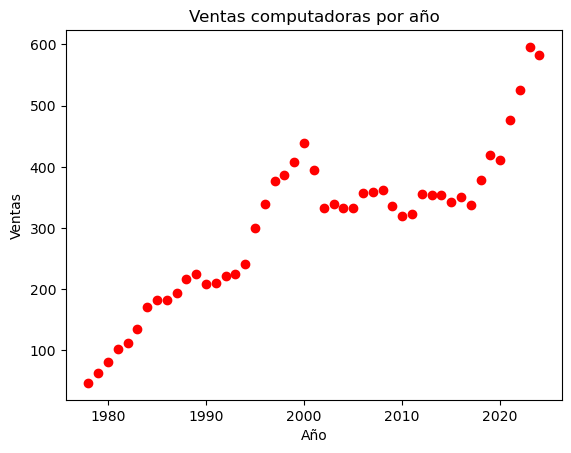

In [17]:
plt.scatter(X,Y, color ="red")
plt.title("Ventas computadoras por año")
plt.xlabel("Año")
plt.ylabel("Ventas")
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state = 1)

In [19]:
print(X_train)

[1997 2014 2024 2011 2001 2012 2005 1999 1991 2016 1995 2020 1982 2006
 1992 1988 2019 2008 2009 2018 1998 1996 2003 1984 1985 2022 1979 1994
 1978 1993 1983 1989 1987 1986 1990 2021 2015]


In [20]:
print(X_test)

[2002 2000 2017 2013 1980 1981 2007 2010 2023 2004]


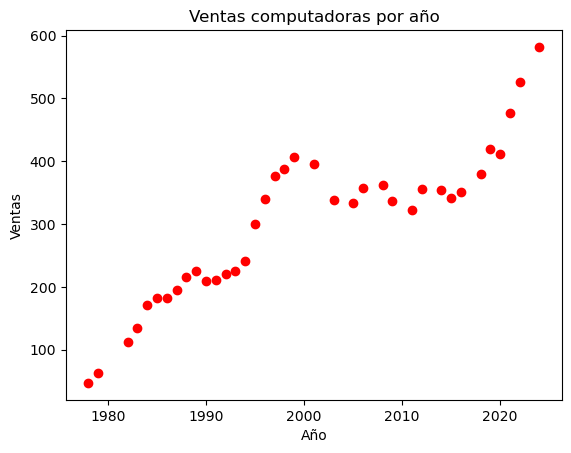

In [21]:
plt.scatter(X_train,Y_train, color ="red")
plt.title("Ventas computadoras por año")
plt.xlabel("Año")
plt.ylabel("Ventas")
plt.show()

In [22]:
X_train = X_train.reshape(-1,1)
X_test = X_test.reshape(-1,1)
Y_train = Y_train.reshape(-1,1)
Y_test = Y_test.reshape(-1,1)

In [23]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train, Y_train)

LinearRegression()

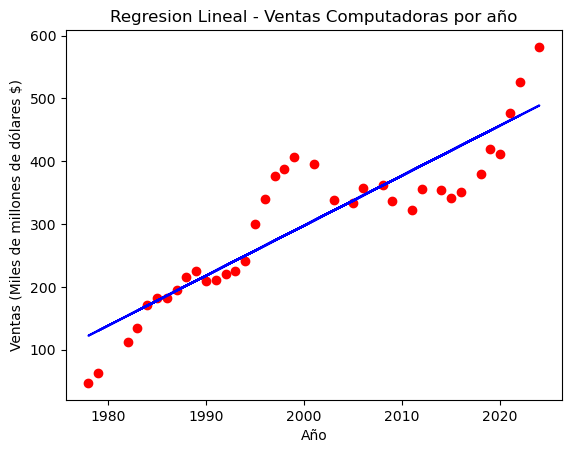

In [24]:
plt.scatter(X_train, Y_train, color = 'red')
plt.plot(X_train, lin_reg.predict(X_train), color = 'blue')
plt.title('Regresion Lineal - Ventas Computadoras por año')
plt.xlabel('Año')
plt.ylabel('Ventas (Miles de millones de dólares $)')
plt.show()

In [25]:
r2_determination_2 = lin_reg.score(X_train,Y_train)

In [26]:
print(f"R^2 REGRESION LINEAL={r2_determination_2}")

R^2 REGRESION LINEAL=0.8051011200090025


In [27]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree = 4)
X_poly_train = poly_reg.fit_transform(X_train)
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly_train, Y_train)

LinearRegression()

In [28]:
#HACEMOS SORT PORQUE AUNQUE HAGAMOS EL ENTRENAMIENTO EL PLOT DENTRO DEL PLT, NO VA A IR EN ORDEN
#AUNQUE ESTO NO SE VEA EN LA LINEAL, ES PORQUE CUANDO ES UNA LINEA SALTA DENTRO DE LA LINEA, PERO COMO ESTAMOS EN UNA 
#FUNCION POLINOMICA, ENTONCES IRA SALTANDO DE PUNTO EN PUNTO Y NO SE VERA TAN BIEN 
#NOTA:  ESTO LO HACEMOS PARA VER LAS GRAFICAS


#AQUI ORDENAMOS LAS X
X_train_sorted = np.sort(X_train, axis=0)

#TRANSFORMAMOS A POLINOMICA LAS X ORDENADAS
X_poly_train_sorted = poly_reg.transform(X_train_sorted)

#OBTENEMOS LA LINEA PREDICTIVA POLINÓMICA
Y_pred_train = lin_reg_2.predict(X_poly_train_sorted)

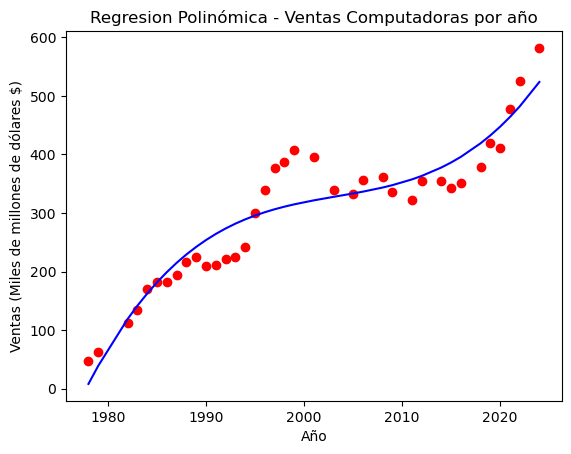

In [29]:
plt.scatter(X_train, Y_train, color = 'red')
plt.plot(X_train_sorted,Y_pred_train , color = 'blue')
plt.title('Regresion Polinómica - Ventas Computadoras por año')
plt.xlabel('Año')
plt.ylabel('Ventas (Miles de millones de dólares $)')
plt.show()

In [30]:
#USAMOS LA MISMA QUE USAMOS PARA ENTRENAR EL MODELO EL X_POLY_TRAIN
r2_determination_train= lin_reg_2.score(X_poly_train,Y_train)

In [31]:
print(f"R^2 POLINOMICO TRAIN = {r2_determination_train}")

R^2 POLINOMICO TRAIN = 0.8913153413651076


In [32]:
#ORDENAMOS DE IGUAL MANERA LAS X_TEST PARA SU PLOT

X_test_sorted = np.sort(X_test,axis=0)
X_test_sorted_poly = poly_reg.transform(X_test_sorted)
Y_pred_test=lin_reg_2.predict(X_test_sorted_poly)

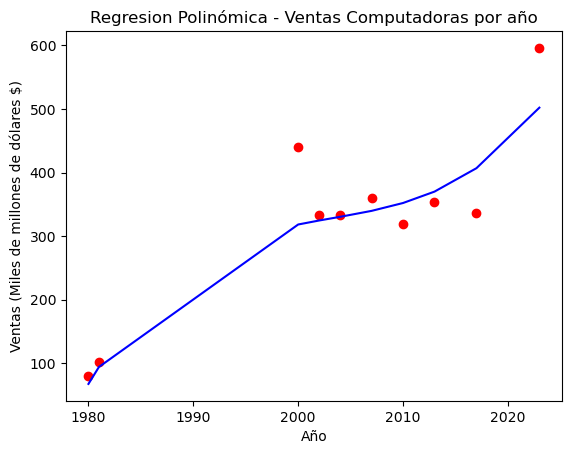

In [33]:
plt.scatter(X_test, Y_test, color = 'red')
plt.plot(X_test_sorted,Y_pred_test , color = 'blue')
plt.title('Regresion Polinómica - Ventas Computadoras por año')
plt.xlabel('Año')
plt.ylabel('Ventas (Miles de millones de dólares $)')
plt.show()

In [34]:
X_test_poly = poly_reg.fit_transform(X_test)
r2_determination_test= lin_reg_2.score(X_test_poly,Y_test)
print(f"R^2 POLINOMICO TEST = {r2_determination_test}")

R^2 POLINOMICO TEST = 0.8464747902377127


In [37]:
#MAE DEL MODELO LINEAL VS MODELO POLINOMIAL
from sklearn.metrics import mean_absolute_error
mae_lineal = mean_absolute_error(Y_test, lin_reg.predict(X_test))
print(f"MAE REGRESION LINEAL={mae_lineal}")
mae_polynomial = mean_absolute_error(Y_test, lin_reg_2.predict(X_test_poly))
print(f"MAE REGRESION POLINOMIAL TEST={mae_polynomial}")

MAE REGRESION LINEAL=58.64123391254407
MAE REGRESION POLINOMIAL TEST=38.40827924355269


In [ ]:
#SI EL MAE DEL MODELO POLINOMIAL ES MENOR AL DEL MODELO LINEAL, ENTONCES EL MODELO POLINOMIAL ES MEJOR
#ADEMAS SI EL MAE DEL MODELO POLINOMIAL EN TRAINING ES MENOR AL DE TEST, ENTONCES NO HAY OVERFITTING

mae_polynomial_train = mean_absolute_error(Y_train, lin_reg_2.predict(X_poly_train))
print(f"MAE REGRESION POLINOMIAL TRAIN={mae_polynomial_train}")

MAE REGRESION POLINOMIAL TRAIN=31.94859279835545
